In [1]:
from auditoryforage.utils import open_pickle_file
folder_name = './store/comparison/'
file_name = folder_name + 'diff_food_rewards.pkl'
detection_measures = open_pickle_file(file_name)

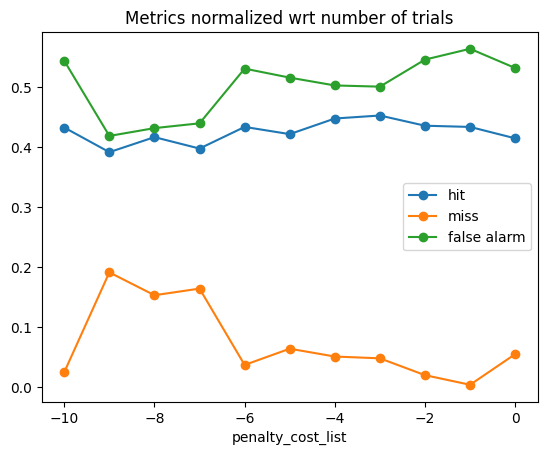

In [12]:
import numpy as np
import matplotlib.pyplot as plt
# food_reward_list = detection_measures['input']['food_reward_list']
penalty_cost_list = detection_measures['input']['penalty_cost_list']
# max_food_ind = len(food_reward_list)

# Plotting any one seed
max_ind_list = detection_measures['output']['best_seed_list']

max_ind = len(max_ind_list)

max_hit_count_normalized = [np.array(count[max_ind_list[ind]])/detection_measures['input']['no_episodes'] for ind, count in enumerate(detection_measures['output']['hit_count_list'])]
max_miss_count_normalized = [np.array(count[max_ind_list[ind]])/detection_measures['input']['no_episodes'] for ind, count in enumerate(detection_measures['output']['miss_count_list'])]
max_false_alarm_count_normalized = [count[max_ind_list[ind]]/detection_measures['input']['no_episodes'] for ind, count in enumerate(detection_measures['output']['false_alarm_list'])]
plt.plot(penalty_cost_list[:max_ind], max_hit_count_normalized[:max_ind], 'o-')
plt.plot(penalty_cost_list[:max_ind], max_miss_count_normalized[:max_ind], 'o-')
plt.plot(penalty_cost_list[:max_ind], max_false_alarm_count_normalized[:max_ind], 'o-')
plt.legend(['hit', 'miss', 'false alarm'])
plt.xlabel('penalty_cost_list')
plt.title('Metrics normalized wrt number of trials')
plt.show()

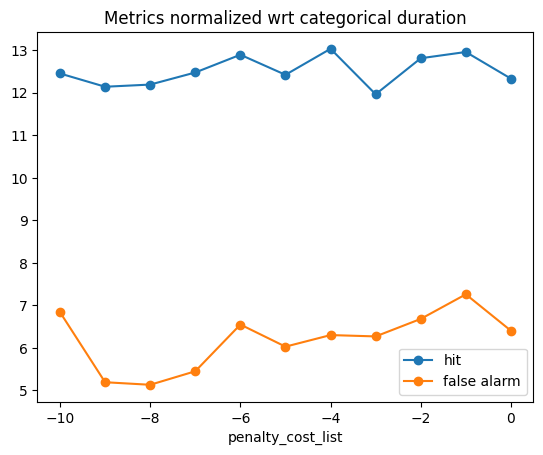

In [14]:
import numpy as np
import matplotlib.pyplot as plt
one_step_in_seconds = .001

temp_zip = zip(np.arange(len(max_ind_list)), detection_measures['output']['hit_count_list'], detection_measures['output']['signal_time_before_lick_list'])
max_hit_rate = [np.divide(count[max_ind_list[ind]],(duration[max_ind_list[ind]] * one_step_in_seconds)) for ind, count, duration in temp_zip]
temp_zip = zip(np.arange(len(max_ind_list)), detection_measures['output']['false_alarm_list'], detection_measures['output']['noise_time_before_lick_list'])
max_false_alarm_rate = [np.array(count[max_ind_list[ind]])/(duration[max_ind_list[ind]] * one_step_in_seconds) for ind, count, duration in temp_zip]
plt.plot(penalty_cost_list[:max_ind], max_hit_rate[:max_ind], 'o-')
plt.plot(penalty_cost_list[:max_ind], max_false_alarm_rate[:max_ind], 'o-')
plt.legend(['hit', 'false alarm'])
plt.xlabel('penalty_cost_list')
plt.title('Metrics normalized wrt categorical duration')
plt.show()

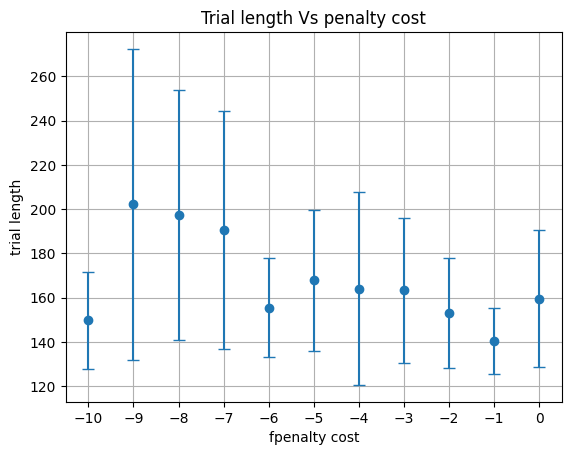

In [18]:
attention_time_points_list = detection_measures['output']['attention_time_points_list']
episode_length_list = detection_measures['output']['episode_length_list']

episode_length_mean_list = []
episode_length_std_list = []

variable_list = [episode_length_list]
variable = episode_length_list
mean_list = []
std_list = []
for exp_ind in range(len(episode_length_list)):
    mean_list.append([np.mean(elt) for elt in variable[exp_ind]])
    std_list.append([np.std(elt) for elt in variable[exp_ind]])
variable_mean_list_chosen = [mean_list[ind][max_ind_list[ind]] for ind in range(len(max_ind_list))]
variable_std_list_chosen = [std_list[ind][max_ind_list[ind]] for ind in range(len(max_ind_list))]
plt.figure()
plt.errorbar(penalty_cost_list, variable_mean_list_chosen, yerr= variable_std_list_chosen, fmt='o', markersize=6, capsize=4)
plt.xlabel('fpenalty cost')
variable_name = [name for name, value in globals().items() if value is variable][0]
plt.ylabel(f'trial length')
plt.title(f'Trial length Vs penalty cost')
plt.xticks(penalty_cost_list)  # Set x-axis labels to column indices
plt.grid()
plt.show()

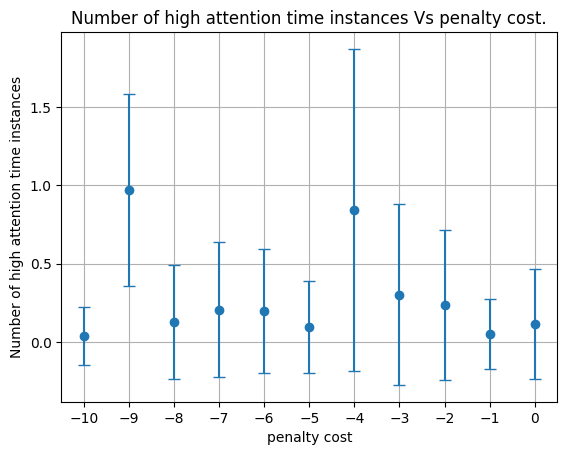

In [19]:
chosen_attention_time_points_list = [attention_time_points_list[ind][max_ind_list[ind]] for ind in range(len(max_ind_list))]

variable_mean_list_chosen = []
variable_std_list_chosen = []
for ind in range(len(chosen_attention_time_points_list)):

    # Correct
    variable_mean_list_chosen.append(np.mean([len(episode) for episode in chosen_attention_time_points_list[ind]]))
    variable_std_list_chosen.append(np.std([len(episode) for episode in chosen_attention_time_points_list[ind]]))

    
plt.figure()
plt.errorbar(penalty_cost_list, variable_mean_list_chosen, yerr= variable_std_list_chosen, fmt='o', markersize=6, capsize=4)
plt.xlabel('penalty cost')
plt.ylabel(f'Number of high attention time instances')
plt.title(f'Number of high attention time instances Vs penalty cost.')
plt.xticks(penalty_cost_list)  # Set x-axis labels to column indices
plt.grid()
plt.show()

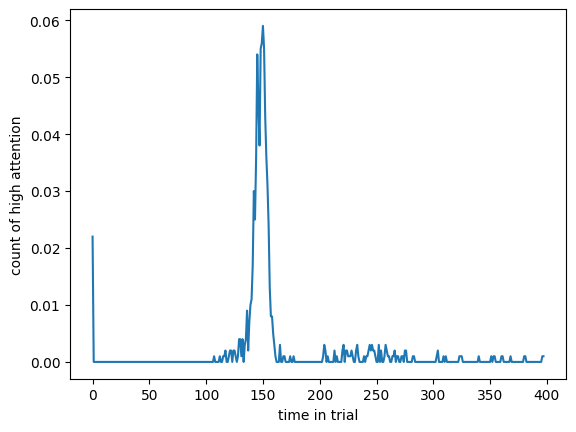

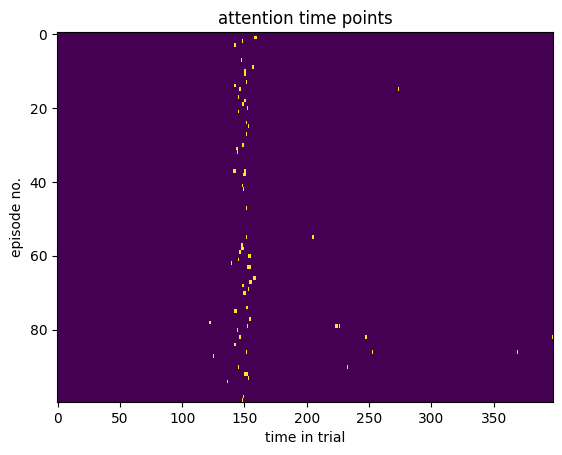

In [39]:
import numpy as np
import matplotlib.pyplot as plt


def pad_zero_attention(data):
    num_rows = len(data)
    num_cols = max(max(arr) for arr in data if len(arr) != 0) + 1
    grid = np.zeros((num_rows, num_cols))
    for i, arr in enumerate(data):
        grid[i, arr] = 1
    return grid


exp_index = 4
num_episodes = 1000
data = chosen_attention_time_points_list[exp_index][:num_episodes]
plt.figure()
plt.plot(np.sum(pad_zero_attention(data), axis = 0)/num_episodes)
plt.xlabel('time in trial')
plt.ylabel('count of high attention')
plt.show()


num_episodes = 100
data = chosen_attention_time_points_list[exp_index][:num_episodes]
plt.imshow(pad_zero_attention(data), cmap='viridis', aspect='auto', interpolation='none')
plt.xlabel('time in trial')
plt.ylabel('episode no.')
plt.title('attention time points')
plt.show()

In [27]:
penalty_cost_list

[0, -1, -2, -3, -4, -5, -6, -7, -8, -9, -10]